# $\mathcal{U}^{900} \in \mathbb{R}^{3072}$

### Setup environment

In [1]:
import sys, os, importlib
print(sys.path)

PATH_ROOT  = "/root/workspace/Python/flipd/"
PATH_MODEL = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


### Load data

In [2]:
from models.training import LightweightTrainer
from models.diffusions.training import LightningDiffusion
from functools import partial
import torch.optim as optim
import torch
import numpy as np
from tqdm import tqdm

from models.diffusions.sdes import VpSde, VeSde
from models.diffusions.networks import MLPUnet

device = torch.device('cuda:4')

2026-01-22 08:29:57.622900: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-22 08:29:57.636746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-22 08:29:57.653467: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-22 08:29:57.658564: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-22 08:29:57.671110: I tensorflow/core/platform/cpu_feature_guar

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [3]:
import matplotlib.pyplot as plt
import visualization.scatterplots as scatterplots
importlib.reload(scatterplots)
from visualization.scatterplots import visualize_3d_clusters
from visualization.pretty import ColorTheme

from data.distributions import AffineManifoldMixture
from data.datasets.generated import LIDSyntheticDataset

ambient_dim = 3072

distribution = AffineManifoldMixture(
    manifold_dims=[900],
    ambient_dim=ambient_dim,
    sample_distr="uniform",
    affine_projection_type="random-rotation",
    seed=111,
    distance_between_modes=10,
)

dset = LIDSyntheticDataset(size=5000, distribution=distribution, standardize=True, seed=42)

/opt/conda/lib/python3.10/site-packages/torch/random.py:166: UserWarning: CUDA reports that you have 8 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)


In [4]:
import gc, torch, contextlib
def free_cuda(*objs):
    # drop strong refs
    for o in objs:
        try:
            del o
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()  # helpful in notebooks
        print("GPU freed.",
              "alloc=", round(torch.cuda.memory_allocated()/1e6,1), "MB,",
              "reserved=", round(torch.cuda.memory_reserved()/1e6,1), "MB")
#free_cuda(trainer, vp_sde, score_net, adapter)  # anything large

### Train VP SDE

In [5]:
from models.diffusions.networks import UNet2D

ambient_dim_img = (3, 32, 32)

IS_CONV2D_LIGHT = False
if IS_CONV2D_LIGHT:
    score_net = UNet2D(
        sample_size=32, in_channels=3,out_channels=3, layers_per_block=2,
        block_out_channels=(128, 128),
        down_block_types=("DownBlock2D", "AttnDownBlock2D"),
        up_block_types=("AttnUpBlock2D", "UpBlock2D",),
        t_factor=1000,   # matches your adapter’s timestep scaling
    ).to(device)
    ckpt_path= os.path.join(PATH_MODEL, "3072D_900d_uniform_idr_unet2d_vp")
else:
    score_net = UNet2D(
        sample_size=32, in_channels=3,out_channels=3, layers_per_block=2,
        block_out_channels=(128, 256, 256),
        down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
        up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
        t_factor=1000,
    ).to(device)
    ckpt_path= os.path.join(PATH_MODEL, "3072D_900d_uniform_idr_unet2d_rich_vp")

class UNet2DFlatAdapter(torch.nn.Module):
    """
    Wrap a trained UNet2D that expects (B,1,28,28) so it can be used
    with flat inputs (B,784) and returns flat outputs (B,784).
    """
    def __init__(self, unet2d: torch.nn.Module, H: int = 32, W: int = 32, C: int = 3):
        super().__init__()
        self.unet2d = unet2d   # your trained UNet2D (diffusers adapter)
        self.H, self.W, self.C = H, W, C
        self.D = C * H * W

    def forward(self, x, t):
        # x can be (B,D) or already (B,C,H,W)
        if x.ndim == 2:
            B = x.shape[0]
            x = x.view(B, self.C, self.H, self.W)
        elif x.ndim == 4:
            B = x.shape[0]
        else:
            raise ValueError(f"Expected x.ndim in {{2,4}}, got {x.ndim}")
        out = self.unet2d(x, t)          # (B,1,28,28)
        return out.view(B, self.D)       # flatten back to (B,D)

adapter = UNet2DFlatAdapter(score_net, H=32, W=32, C=3).to(device)
vp_sde = VpSde(score_net=adapter).to(device)

print(ckpt_path)
trainer = LightweightTrainer(max_epochs=371, device=device,)
trainer.fit(
    model=LightningDiffusion(sde=vp_sde, optim_partial=partial(optim.Adam, lr=1e-4)),
    train_dataloader=torch.utils.data.DataLoader(dset.x, batch_size=500, shuffle=True),
    ckpt_path=ckpt_path,
)

/root/workspace/Python/flipd/notebooks/outputs/notebooks/3072D_900d_uniform_idr_unet2d_rich_vp


Training: 100%|██████████| 371/371 [00:00<?, ?it/s]


In [6]:
from visualization import visualize_3d_clusters
from visualization import visualize_umap_clusters
from visualization.pretty import ColorTheme

n_samples = 500

if False:
    noise = torch.randn(n_samples, ambient_dim).to(device)
    vp_sde: VpSde
    gen_samples = vp_sde.solve_reverse_sde(noise, steps=1000)

    visualize_umap_clusters(
        data = [gen_samples.cpu().detach().numpy(), dset.x[:n_samples].cpu().numpy()],
        labels=["generated", "real"],
        title="quality of model",
        alpha=0.3,
        colors=[ColorTheme.GOLD.value, ColorTheme.BLUE_SECOND.value],
        return_img=False,
    )

### Generate and visualize samples to check the model trained properly

## LID Estimation

In [7]:
# reload for debug 
import importlib, sys
importlib.invalidate_caches()

import lid.base as lid_base
importlib.reload(lid_base)

from lid.diffusions import local_hessian_spectrum as lhs
importlib.reload(lhs)

import lid.diffusions as lid_diffusions
importlib.reload(lid_diffusions)

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)
from lid.evaluation.lid_evaluation import mae

In [9]:
from lid.evaluation.lid_evaluation import mae
import numpy as np

n_samples = 500

# Initialize estimator
lid_estimator_soft_dof = LocalHessianSpectralEstimator(
    vp_sde, 
    VPSchedule(beta_min=0.1, beta_max=20.0), 
    method="Soft_DoF", 
    soft_c=0.1, 
    soft_p=4,
    ambient_dim=ambient_dim, 
    device=device, 
    batch_size=n_samples,
    lanczos_m=2 # Default, will be overridden in the loop
)

data = dset.x[:n_samples].to(device)
gt_lid = dset.lid[:n_samples].to(device).cpu().numpy()

deltas = np.linspace(0.001, 0.2, 8)
m_steps_list = [2, 5, 10, 20]

for m in m_steps_list:
    print(f"--- Evaluating with Lanczos steps m={m} ---")
    for delta in deltas:
        # Override lanczos_m dynamically
        lid_soft_dof = lid_estimator_soft_dof.estimate_lid(
            data, 
            delta=delta, 
            lanczos_m=m
        ).cpu().numpy()
        
        error = mae(lid_soft_dof, gt_lid)
        print(f'SoftDoF (m={m}): delta={delta:.5f}, MAE={error:.6f}')
    print("-" * 40)

--- Evaluating with Lanczos steps m=2 ---
SoftDoF (m=2): delta=0.00100, MAE=2171.923131
SoftDoF (m=2): delta=0.02943, MAE=155.776625
SoftDoF (m=2): delta=0.05786, MAE=120.405665
SoftDoF (m=2): delta=0.08629, MAE=67.657813
SoftDoF (m=2): delta=0.11471, MAE=52.098920
SoftDoF (m=2): delta=0.14314, MAE=294.813603
SoftDoF (m=2): delta=0.17157, MAE=571.845376
SoftDoF (m=2): delta=0.20000, MAE=755.345187
----------------------------------------
--- Evaluating with Lanczos steps m=5 ---
SoftDoF (m=5): delta=0.00100, MAE=2171.921215
SoftDoF (m=5): delta=0.02943, MAE=11.529213
SoftDoF (m=5): delta=0.05786, MAE=14.574374
SoftDoF (m=5): delta=0.08629, MAE=36.011126
SoftDoF (m=5): delta=0.11471, MAE=104.242898
SoftDoF (m=5): delta=0.14314, MAE=251.058742
SoftDoF (m=5): delta=0.17157, MAE=421.512060
SoftDoF (m=5): delta=0.20000, MAE=547.717389
----------------------------------------
--- Evaluating with Lanczos steps m=10 ---
SoftDoF (m=10): delta=0.00100, MAE=2171.922235
SoftDoF (m=10): delta=0.029

In [19]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import measure_inference_time

m_steps_list = [2, 5, 10, 20, 40]

print(f"{'Lanczos Steps (m)':<20} | {'Inference Time (ms)':<20}")
print("-" * 45)
delta = 0.029428571428571432

time_results = {}

for m in m_steps_list:
    t_ms = measure_inference_time(
        estimator=lid_estimator_soft_dof,
        x=data,  t=delta, lanczos_m=m 
    )
    
    time_results[m] = t_ms
    print(f"{m:<20} | {t_ms:.2f}")

print("-" * 45)

Lanczos Steps (m)    | Inference Time (ms) 
---------------------------------------------
2                    | 3257.82
5                    | 8144.26
10                   | 16285.72
20                   | 32568.39
40                   | 67215.32
---------------------------------------------


In [ ]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

delta = 0.02943
m = 10
lid_soft_dof = lid_estimator_soft_dof.estimate_lid(data, delta=delta, lanczos_m=10).cpu().numpy()

filename = os.path.join(PATH_FIG, "3072D_900d_uniform")
plot_histograms([lid_soft_dof], labels=['LHSD'], filename=filename)

3072D_900d_uniform_hessian_spectrum_t_0.6.png
Computing eigenvalues for 20 samples (Dimension=3072)...


Computing Hessian (3072 dims): 100%|██████████| 3072/3072 [00:23<00:00, 128.26it/s]


... saved /root/workspace/Python/flipd/notebooks/figs/3072D_900d_uniform_hessian_spectrum_t_0.6.png


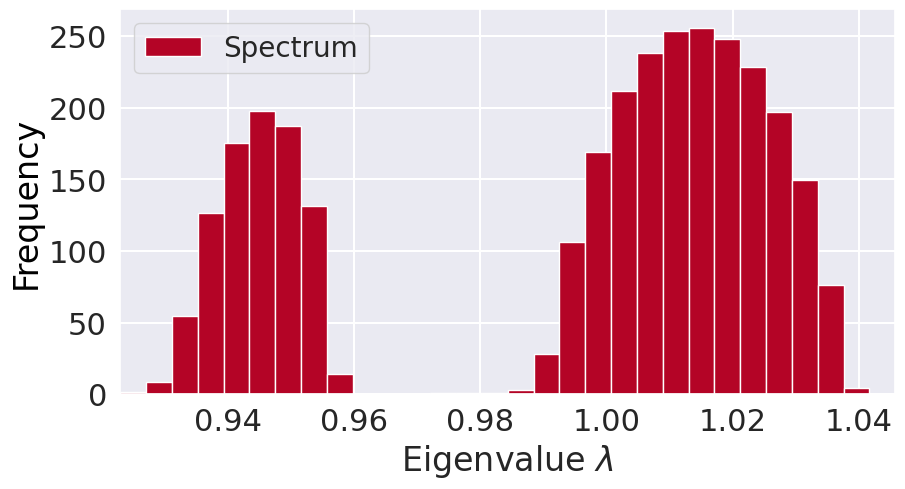

In [48]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import plot_eigenvalue_spectrum_with_filter
delta_t = 0.6
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)
sigma2 = schedule.sigma2(delta_t)

x = data[:20].to(device)
sigma_val = np.sqrt(sigma2)
z = torch.randn_like(x)
x_noisy = x + sigma_val * z

print("3072D_900d_uniform_hessian_spectrum_t_%s.png"%(delta_t))

pairs = [
    [0.1, 4], 
    #[0.1, 12], 
    #[0.2, 4],
    #[0.2, 12], 
    #[0.3, 4],
    #[0.3, 12],
]

_ = plot_eigenvalue_spectrum_with_filter(
    sde=vp_sde,  # Adapter SDE
    x_batch=x_noisy, 
    t_val=delta_t, 
    sigma2_val=schedule.sigma2(delta_t),
    p_c_pairs=pairs,
    filename=os.path.join(PATH_FIG, "3072D_900d_uniform_hessian_spectrum_t_%s.png"%(delta_t))
)


Sweep t (Transition mass; B=20, D=3072): 100%|██████████| 20/20 [08:25<00:00, 25.30s/it]


... saved /root/workspace/Python/flipd/notebooks/figs/FilterDiag/3072D_900d_uniform.png


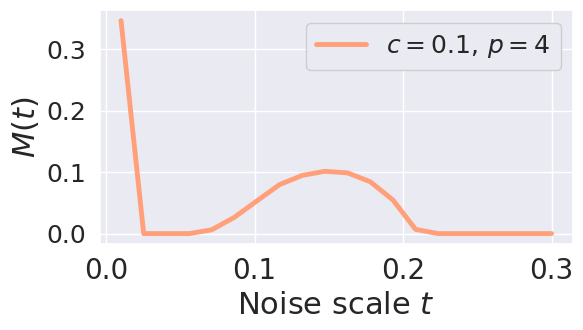

In [42]:
import notebooks.utils.utils as utils 
importlib.reload(utils)
from notebooks.utils.utils import plot_transition_mass_over_t

delta_list = np.linspace(0.01, 0.3, 20)
schedule = VPSchedule(beta_min=0.1, beta_max=20.0)

pairs = [
    [0.1, 4],
    #[0.2, 4],
    #[0.1, 12],
]

res = plot_transition_mass_over_t(
    sde=vp_sde,
    schedule=schedule,
    x_batch=data[:20].to(device),
    t_list=delta_list,
    p_c_pairs=pairs,
    eps_rel=0.2,
    filename=os.path.join(PATH_FIG, "FilterDiag", "3072D_900d_uniform"),
)

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [11]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=ambient_dim, device=device,)

delta = 0.143142857142857
lid = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
print('NB:', delta, mae(lid, gt_lid))
delta = 0.171571428571428
lid = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
print('NB:', delta, mae(lid, gt_lid))
delta = 0.2
lid = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
print('NB:', delta, mae(lid, gt_lid))


deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid = lid_estimator_nb.estimate_lid(data, noise_time=delta).detach().cpu().numpy()
    print('NB:', delta, mae(lid, gt_lid))

NB: 0.143142857142857 2171.0
NB: 0.171571428571428 2171.0
NB: 0.2 2171.0
NB: 0.001 2171.0
NB: 0.029428571428571432 2171.0
NB: 0.057857142857142864 2171.0
NB: 0.0862857142857143 2171.0
NB: 0.11471428571428573 2171.0
NB: 0.14314285714285716 2171.0
NB: 0.1715714285714286 2171.0
NB: 0.2 2171.0


## Competitor - LIDL

In [12]:
from lid.diffusions.fokker_planck import FPRegressEstimator
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_lidl.estimate_lid(data, delta=1e-3).detach().cpu().numpy()
print('LIDL:', mae(lid, gt_lid))

LIDL: 2175.7778178710937


## Competitor - FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
n_samples = 500
deltas = np.linspace(0.001, 0.2, 8)
for delta in deltas:
    lid = lid_estimator_flipd.estimate_lid(data, t=delta).detach().cpu().numpy()
    print('FLIPD:', delta, mae(lid, gt_lid))

FLIPD: 0.001 2172.224440917969
FLIPD: 0.029428571428571432 1749.1292236328125
FLIPD: 0.057857142857142864 999.5866140136719
FLIPD: 0.0862857142857143 538.6505163574219
FLIPD: 0.11471428571428573 288.2300170898437
FLIPD: 0.14314285714285716 152.69417749023438


## Competitor - ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
n_samples = 500
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="ESS")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS:', mae(lid, gt_lid))

In [ ]:
data_train = dset.x[-10000:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="ESS")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))

est.fit(n_neighbors=200)
lid = est.estimate_lid(data).cpu().numpy()
print('ESS 10k:', mae(lid, gt_lid))

## Competitor - LPCA

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="lPCA")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA:', mae(lid, gt_lid))

In [ ]:
data_train = dset.x[-10000:]

est = SkdimLIDEstimator(data=data_train, ambient_dim=ambient_dim, estimator_type="lPCA")
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA 10k:', mae(lid, gt_lid))

est.fit(n_neighbors=200)
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA 10k:', mae(lid, gt_lid))